In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# ============================================================
# 1. CARGAR LOS DATASETS
# ============================================================
train_df = pd.read_csv(r"C:\Users\Ing. Antonio Rial\OneDrive - Universidad Austral\MCD_Laboratorio.de.Implementación.2\Competencia.House.Pricing\data\tabular\train_processed.csv", low_memory=False)
test_df = pd.read_csv(r"C:\Users\Ing. Antonio Rial\OneDrive - Universidad Austral\MCD_Laboratorio.de.Implementación.2\Competencia.House.Pricing\data\tabular\test_processed.csv", low_memory=False)
print("Datos de entrenamiento:", train_df.shape)
print("Datos de prueba:", test_df.shape)

Datos de entrenamiento: (11840, 46)
Datos de prueba: (5038, 44)


---

In [15]:
# ============================================================
# 1. RESUMEN GENERAL DE VALORES FALTANTES
# ============================================================
print("=" * 70)
print("1. RESUMEN GENERAL DE VALORES FALTANTES")
print("=" * 70)

total_celdas = train_df.shape[0] * train_df.shape[1]
total_nulos = train_df.isnull().sum().sum()
pct_nulos_total = (total_nulos / total_celdas) * 100

print(f"Total de celdas en el dataset:     {total_celdas:,}")
print(f"Total de valores faltantes:        {total_nulos:,}")
print(f"Porcentaje global de faltantes:    {pct_nulos_total:.2f}%")
print(f"Filas con al menos un faltante:    {train_df.isnull().any(axis=1).sum():,} ({train_df.isnull().any(axis=1).sum()/len(train_df)*100:.2f}%)")
print(f"Filas completas (sin faltantes):   {train_df.dropna().shape[0]:,} ({train_df.dropna().shape[0]/len(train_df)*100:.2f}%)")

1. RESUMEN GENERAL DE VALORES FALTANTES
Total de celdas en el dataset:     544,640
Total de valores faltantes:        18,522
Porcentaje global de faltantes:    3.40%
Filas con al menos un faltante:    7,883 (66.58%)
Filas completas (sin faltantes):   3,957 (33.42%)


In [16]:
# ============================================================
# 2. DETALLE POR COLUMNA
# ============================================================
print("\n" + "=" * 70)
print("2. DETALLE DE VALORES FALTANTES POR COLUMNA")
print("=" * 70)

missing = pd.DataFrame({
    'Columna': train_df.columns,
    'Tipo': train_df.dtypes.values,
    'No_Nulos': train_df.count().values,
    'Nulos': train_df.isnull().sum().values,
    'Pct_Nulos': (train_df.isnull().sum().values / len(train_df) * 100).round(2),
    'Valores_Unicos': [train_df[col].nunique() for col in train_df.columns]
})
missing = missing.sort_values('Pct_Nulos', ascending=False)
missing['Severidad'] = missing['Pct_Nulos'].apply(
    lambda x: '🔴 CRÍTICO (>40%)' if x > 40 
    else '🟠 ALTO (20-40%)' if x > 20 
    else '🟡 MODERADO (5-20%)' if x > 5 
    else '🟢 BAJO (<5%)' if x > 0 
    else '✅ COMPLETO'
)

print(missing.to_string(index=False))


2. DETALLE DE VALORES FALTANTES POR COLUMNA
                   Columna    Tipo  No_Nulos  Nulos  Pct_Nulos  Valores_Unicos        Severidad
              lotAreaValue float64      6494   5346      45.15            2083 🔴 CRÍTICO (>40%)
              log_lot_area float64      6494   5346      45.15            2083 🔴 CRÍTICO (>40%)
        last_listing_price float64      7915   3925      33.15            1593  🟠 ALTO (20-40%)
         bath_to_bed_ratio float64     11258    582       4.92              38     🟢 BAJO (<5%)
           latest_tax_paid float64     11301    539       4.55           10505     🟢 BAJO (<5%)
          taxAssessedValue float64     11316    524       4.43           10381     🟢 BAJO (<5%)
          latest_tax_value float64     11315    525       4.43           10380     🟢 BAJO (<5%)
                  bedrooms float64     11360    480       4.05              11     🟢 BAJO (<5%)
              property_age float64     11529    311       2.63             110     🟢 BAJO (


✅ Gráfico guardado: missing_values_analysis.png


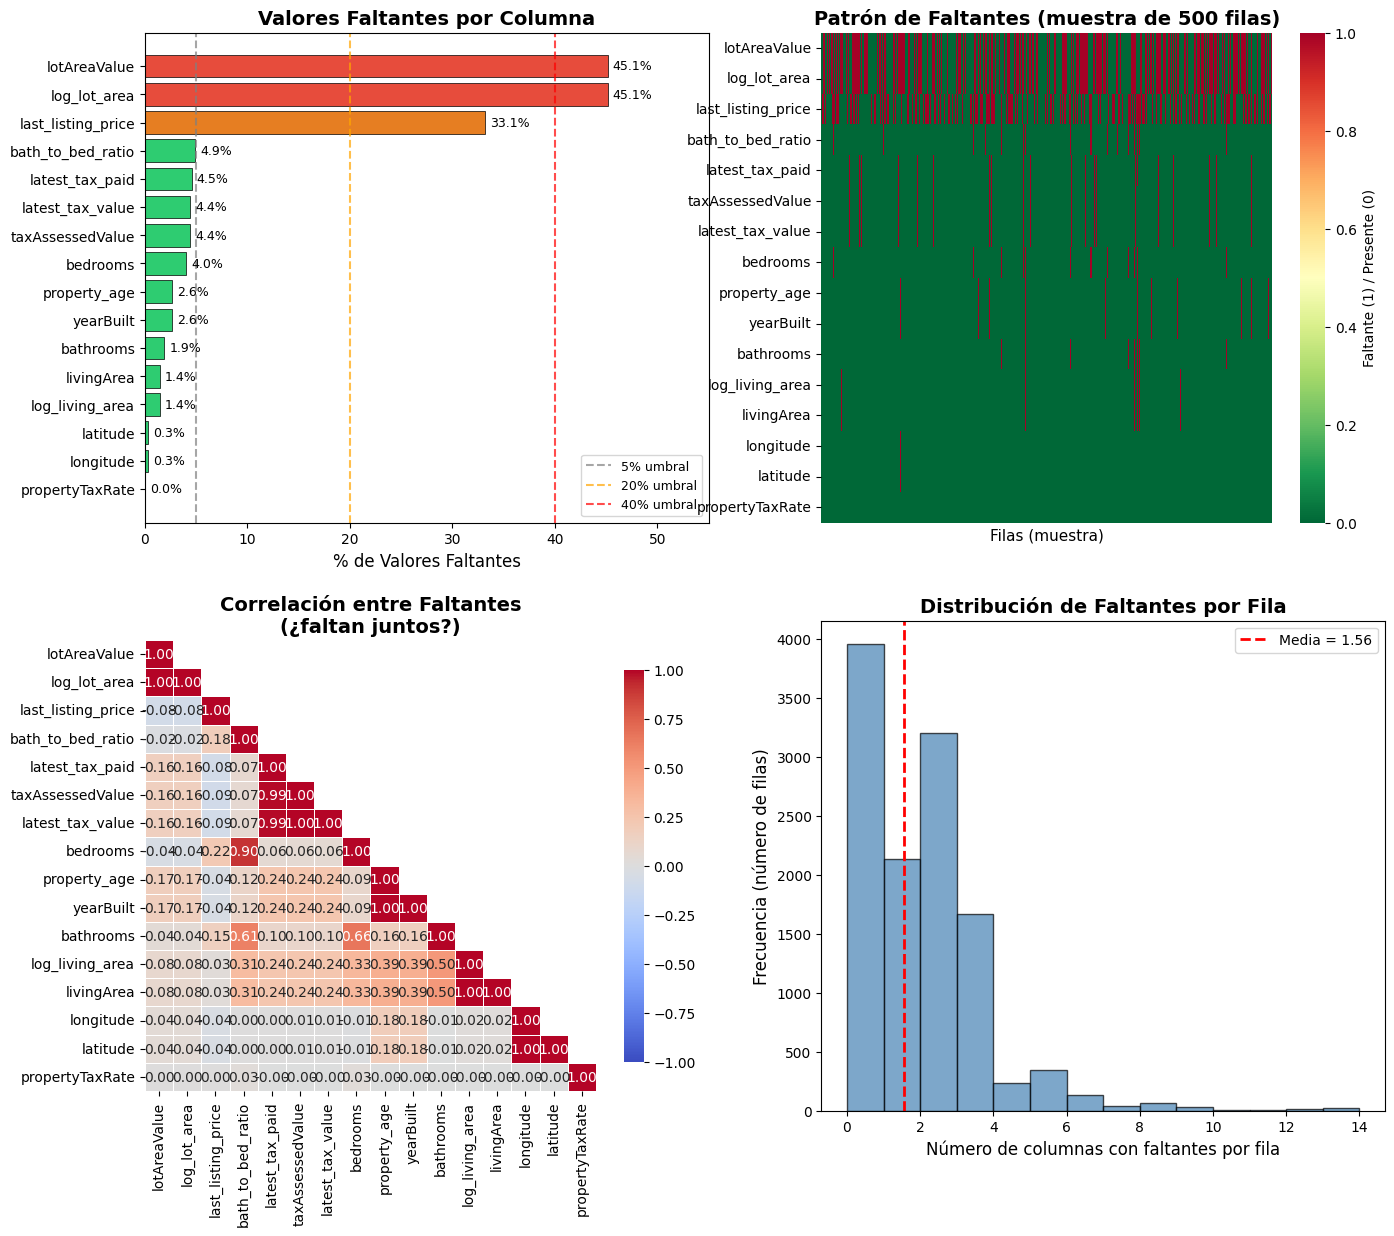

In [19]:
# ============================================================
# 3. VISUALIZACIONES DE VALORES FALTANTES
# ============================================================

# Figura 1: Barras horizontales de % de faltantes por columna
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# --- Gráfico 1: Barras horizontales ---
ax1 = axes[0, 0]
missing_plot = missing[missing['Nulos'] > 0].sort_values('Pct_Nulos', ascending=True)
colors = ['#e74c3c' if x > 40 else '#e67e22' if x > 20 else '#f1c40f' if x > 5 else '#2ecc71' 
          for x in missing_plot['Pct_Nulos']]
bars = ax1.barh(missing_plot['Columna'], missing_plot['Pct_Nulos'], color=colors, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('% de Valores Faltantes', fontsize=12)
ax1.set_title('Valores Faltantes por Columna', fontsize=14, fontweight='bold')
ax1.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='5% umbral')
ax1.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='20% umbral')
ax1.axvline(x=40, color='red', linestyle='--', alpha=0.7, label='40% umbral')
for bar, pct in zip(bars, missing_plot['Pct_Nulos']):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{pct:.1f}%', va='center', fontsize=9)
ax1.legend(loc='lower right', fontsize=9)
ax1.set_xlim(0, 55)

# --- Gráfico 2: Mapa de calor de faltantes (muestra) ---
ax2 = axes[0, 1]
cols_con_nulos = missing[missing['Nulos'] > 0]['Columna'].tolist()
train_df_nulos = train_df[cols_con_nulos].isnull().astype(int)
# Muestra aleatoria de 500 filas para visualización
np.random.seed(42)
sample_idx = np.random.choice(train_df_nulos.index, size=min(500, len(train_df_nulos)), replace=False)
df_sample = train_df_nulos.loc[sample_idx]
sns.heatmap(df_sample.T, cbar=True, cmap='RdYlGn_r', ax=ax2, 
            xticklabels=False, yticklabels=True, cbar_kws={'label': 'Faltante (1) / Presente (0)'})
ax2.set_title('Patrón de Faltantes (muestra de 500 filas)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Filas (muestra)', fontsize=11)

# --- Gráfico 3: Matriz de correlación de faltantes ---
ax3 = axes[1, 0]
# Calcular correlación entre columnas con faltantes (solo las que tienen nulos)
cols_nulos = [c for c in cols_con_nulos if train_df[c].isnull().sum() > 0]
if len(cols_nulos) > 1:
    null_corr = train_df[cols_nulos].isnull().corr()
    mask = np.triu(np.ones_like(null_corr, dtype=bool), k=1)
    sns.heatmap(null_corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, ax=ax3, square=True, linewidths=0.5,
                vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
    ax3.set_title('Correlación entre Faltantes\n(¿faltan juntos?)', fontsize=14, fontweight='bold')
else:
    ax3.text(0.5, 0.5, 'Insuficientes columnas\ncon faltantes', ha='center', va='center', fontsize=12)
    ax3.set_title('Correlación entre Faltantes', fontsize=14, fontweight='bold')

# --- Gráfico 4: Distribución de faltantes por fila ---
ax4 = axes[1, 1]
nulos_por_fila = train_df.isnull().sum(axis=1)
ax4.hist(nulos_por_fila, bins=range(0, nulos_por_fila.max()+2), color='steelblue', 
         edgecolor='black', alpha=0.7)
ax4.set_xlabel('Número de columnas con faltantes por fila', fontsize=12)
ax4.set_ylabel('Frecuencia (número de filas)', fontsize=12)
ax4.set_title('Distribución de Faltantes por Fila', fontsize=14, fontweight='bold')
ax4.axvline(x=nulos_por_fila.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Media = {nulos_por_fila.mean():.2f}')
ax4.legend(fontsize=10)

#plt.tight_layout()
#plt.savefig('/mnt/agents/output/missing_values_analysis.png', dpi=150, bbox_inches='tight')
#plt.show()

print("\n✅ Gráfico guardado: missing_values_analysis.png")

In [21]:
# ============================================================
# 4. ANÁLISIS DE PATRONES DE FALTANTES
# ============================================================
print("=" * 70)
print("4. ANÁLISIS DE PATRONES DE FALTANTES (MCAR, MAR, MNAR)")
print("=" * 70)

# --- Patrón 1: lotAreaValue y log_lot_area ---
print("\n📌 PATRÓN 1: lotAreaValue ↔ log_lot_area")
print("-" * 50)
lot_nulos = train_df['lotAreaValue'].isnull()
loglot_nulos = train_df['log_lot_area'].isnull()
print(f"lotAreaValue faltantes:        {lot_nulos.sum()}")
print(f"log_lot_area faltantes:        {loglot_nulos.sum()}")
print(f"Ambos faltan juntos:           {(lot_nulos & loglot_nulos).sum()}")
print(f"Correlación de faltantes:      {lot_nulos.corr(loglot_nulos):.4f}")
print("→ Son la misma variable transformada. Se pierden juntos (determinístico).")

# --- Patrón 2: Variables fiscales ---
print("\n📌 PATRÓN 2: Variables fiscales (taxAssessedValue, latest_tax_value, latest_tax_paid)")
print("-" * 50)
tax_cols = ['taxAssessedValue', 'latest_tax_value', 'latest_tax_paid']
for col in tax_cols:
    nulos = train_df[col].isnull().sum()
    print(f"{col}: {nulos} faltantes ({nulos/len(train_df)*100:.2f}%)")

# ¿Faltan juntas?
tax_missing = train_df[tax_cols].isnull()
juntas = (tax_missing.sum(axis=1) == 3).sum()
print(f"Filas donde faltan las 3 juntas: {juntas}")
print(f"Correlación taxAssessedValue ↔ latest_tax_value: {tax_missing.iloc[:,0].corr(tax_missing.iloc[:,1]):.4f}")
print(f"Correlación taxAssessedValue ↔ latest_tax_paid:  {tax_missing.iloc[:,0].corr(tax_missing.iloc[:,2]):.4f}")

# --- Patrón 3: bedrooms, bathrooms, livingArea ---
print("\n📌 PATRÓN 3: Características físicas (bedrooms, bathrooms, livingArea)")
print("-" * 50)
phys_cols = ['bedrooms', 'bathrooms', 'livingArea', 'log_living_area', 'bath_to_bed_ratio']
phys_missing = train_df[phys_cols].isnull()
print("Faltantes por columna:")
for col in phys_cols:
    print(f"  {col}: {train_df[col].isnull().sum()}")
print(f"Filas donde faltan bedrooms Y bathrooms: {(train_df['bedrooms'].isnull() & train_df['bathrooms'].isnull()).sum()}")
print(f"Filas donde faltan livingArea Y log_living_area: {(train_df['livingArea'].isnull() & train_df['log_living_area'].isnull()).sum()}")

# --- Patrón 4: yearBuilt ↔ property_age ---
print("\n📌 PATRÓN 4: yearBuilt ↔ property_age")
print("-" * 50)
yb_null = train_df['yearBuilt'].isnull()
pa_null = train_df['property_age'].isnull()
print(f"yearBuilt faltantes:     {yb_null.sum()}")
print(f"property_age faltantes:  {pa_null.sum()}")
print(f"Ambos faltan juntos:     {(yb_null & pa_null).sum()}")
print(f"Correlación:             {yb_null.corr(pa_null):.4f}")
print("→ Son la misma información (property_age = año_actual - yearBuilt).")

# --- Patrón 5: latitude ↔ longitude ---
print("\n📌 PATRÓN 5: latitude ↔ longitude")
print("-" * 50)
lat_null = train_df['latitude'].isnull()
lon_null = train_df['longitude'].isnull()
print(f"latitude faltantes:   {lat_null.sum()}")
print(f"longitude faltantes:  {lon_null.sum()}")
print(f"Ambos faltan juntos:  {(lat_null & lon_null).sum()}")
print(f"Correlación:          {lat_null.corr(lon_null):.4f}")
print("→ Coordenadas geográficas: si falta una, falta la otra.")

4. ANÁLISIS DE PATRONES DE FALTANTES (MCAR, MAR, MNAR)

📌 PATRÓN 1: lotAreaValue ↔ log_lot_area
--------------------------------------------------
lotAreaValue faltantes:        5346
log_lot_area faltantes:        5346
Ambos faltan juntos:           5346
Correlación de faltantes:      1.0000
→ Son la misma variable transformada. Se pierden juntos (determinístico).

📌 PATRÓN 2: Variables fiscales (taxAssessedValue, latest_tax_value, latest_tax_paid)
--------------------------------------------------
taxAssessedValue: 524 faltantes (4.43%)
latest_tax_value: 525 faltantes (4.43%)
latest_tax_paid: 539 faltantes (4.55%)
Filas donde faltan las 3 juntas: 524
Correlación taxAssessedValue ↔ latest_tax_value: 0.9990
Correlación taxAssessedValue ↔ latest_tax_paid:  0.9853

📌 PATRÓN 3: Características físicas (bedrooms, bathrooms, livingArea)
--------------------------------------------------
Faltantes por columna:
  bedrooms: 480
  bathrooms: 225
  livingArea: 172
  log_living_area: 172
  bath_to

#### Estrategias recomendadas según el tipo de columna  
🔢 Variables numéricas continuas (precio, sqft, coordenadas, etc.)  
|Situación|Estrategia recomendada|  
| :--- | :---: |  
|< 5% missing|Mediana (robusta a outliers) o imputación por KNN|
|5-20% missing|Imputación iterativa (IterativeImputer) o modelo predictivo|
|> 20% missing|Evaluar si la columna aporta valor; considerar eliminar o crear flag de missing|

✅ Columnas recomendadas para mediana:  

| Columna | Tipo | Por qué mediana |
|---------|------|-----------------|
| bedrooms | Numérica discreta | Valores como 2, 3, 4; robusta a outliers |
| bathrooms | Numérica (con decimales) | Valores como 2.0, 2.5, 3.0; distribución no normal |
| sqft | Continua | Típicamente sesgada a la derecha, mediana más representativa |
| year_built | Numérica | La mediana evita que valores extremos distorsionen |
| lot_size | Continua | Muy probable que tenga outliers, mediana es robusta |
| price / rent | Continua | Distribución altamente sesgada, mediana >> media |
| hoa_fee, tax_amount (si existen) | Continua | Mismo razonamiento que precio |

In [24]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

#df = pd.read_csv('train_processed.csv')

# Columnas candidatas para mediana (según tu tabla)
median_candidates = ['bedrooms', 'bathrooms', 'sqft', 'year_built', 'lot_size', 'price', 'rent', 'hoa_fee']

# Filtrar solo las que existen en el dataset y tienen missing values
cols_to_impute = [col for col in median_candidates if col in train_df.columns and train_df[col].isnull().any()]

print(f"Columnas a imputar con mediana: {cols_to_impute}")

# Aplicar imputación
if cols_to_impute:
    imputer = SimpleImputer(strategy='median')
    train_df[cols_to_impute] = imputer.fit_transform(train_df[cols_to_impute])
    
    # Opcional: crear flags para variables críticas
    for col in ['price', 'sqft', 'bedrooms']:
        if col in cols_to_impute:
            train_df[f'{col}_was_missing'] = train_df[col].isnull().astype(int)

Columnas a imputar con mediana: ['bedrooms', 'bathrooms']


✅ Columnas candidatas para Imputación Iterativa en tu dataset:  
  
|Columna|Por qué funciona con IterativeImputer|Variables relacionadas para predecir|
|-------|-------------------------------------|------------------------------------|
|price / rent|Altamente correlacionadas con sqft, ubicación, características|sqft, bedrooms, bathrooms, zip_code, property_type|
|sqft|Se relaciona con precio, habitaciones, tipo de propiedad|price, bedrooms, bathrooms, lot_size|
|lot_size|Correlacionada con tipo de propiedad, ubicación, precio|property_type, zip_code, price, year_built|
|year_built|Puede inferirse por estilo, ubicación, valor de la propiedad|property_type, zip_code, price, hoa_fee|
|latitude / longitude|Fuertemente ligadas a zip_code y características del área|zip_code, property_type, price|
|hoa_fee / tax_amount|Dependen del valor de la propiedad y ubicación|price, property_type, zip_code, sqft|

In [26]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd
import numpy as np

#df = pd.read_csv('train_processed.csv')

# Seleccionar columnas numéricas candidatas
iterative_candidates = ['sqft', 'lot_size', 'year_built', 
                        'latitude', 'longitude', 'hoa_fee', 'tax_amount']
#iterative_candidates = ['price', 'sqft', 'lot_size', 'year_built', 
#                        'latitude', 'longitude', 'hoa_fee', 'tax_amount']

# Filtrar solo las que existen y tienen missing
cols_to_impute = [col for col in iterative_candidates if col in train_df.columns and train_df[col].isnull().any()]

if cols_to_impute:
    # Configurar imputador iterativo
    imputer = IterativeImputer(
        random_state=42, 
        max_iter=10, 
        tol=1e-3,
        sample_posterior=False  # Más rápido para datasets grandes
    )
    
    # Aplicar imputación
    train_df[cols_to_impute] = imputer.fit_transform(train_df[cols_to_impute])
    
    print(f"✓ Imputación iterativa aplicada a: {cols_to_impute}")

✓ Imputación iterativa aplicada a: ['latitude', 'longitude']


In [28]:
# 1. Categóricas → categoría 'Missing'
cat_cols = train_df.select_dtypes(include=['object']).columns
train_df[cat_cols] = train_df[cat_cols].fillna('Missing')

# 2. Numéricas con <5% missing → Mediana (rápido)
# 1. Categóricas → categoría 'Missing'
cat_cols = train_df.select_dtypes(include=['object']).columns
train_df[cat_cols] = train_df[cat_cols].fillna('Missing')

# 2. Numéricas con <5% missing → Mediana (rápido)
num_cols = train_df.select_dtypes(include=[np.number]).columns
low_missing = [col for col in num_cols if 0 < train_df[col].isnull().sum() / len(train_df) < 0.05]

if low_missing:
    train_df[low_missing] = SimpleImputer(strategy='median').fit_transform(train_df[low_missing])

# 3. Numéricas con 5-30% missing y correlaciones → IterativeImputer
high_corr_cols = ['price', 'sqft', 'lot_size', 'year_built']  # ajustar según análisis
# 1. Categóricas → categoría 'Missing'
cat_cols = train_df.select_dtypes(include=['object']).columns
train_df[cat_cols] = train_df[cat_cols].fillna('Missing')

# 2. Numéricas con <5% missing → Mediana (rápido)
num_cols = train_df.select_dtypes(include=[np.number]).columns
low_missing = [col for col in num_cols if 0 < train_df[col].isnull().sum() / len(train_df) < 0.05]

if low_missing:
    train_df[low_missing] = SimpleImputer(strategy='median').fit_transform(train_df[low_missing])

# 3. Numéricas con 5-30% missing y correlaciones → IterativeImputer
high_corr_cols = [col for col in num_cols if 0.05 <= train_df[col].isnull().sum() / len(train_df) <= 0.30]

if high_corr_cols:
    train_df[high_corr_cols] = IterativeImputer(random_state=42).fit_transform(train_df[high_corr_cols])
# 1. Categóricas → categoría 'Missing'
cat_cols = train_df.select_dtypes(include=['object']).columns
train_df[cat_cols] = train_df[cat_cols].fillna('Missing')

# 2. Numéricas con <5% missing → Mediana (rápido)
num_cols = train_df.select_dtypes(include=[np.number]).columns
low_missing = [col for col in num_cols if 0 < train_df[col].isnull().sum() / len(train_df) < 0.05]

if low_missing:
    train_df[low_missing] = SimpleImputer(strategy='median').fit_transform(train_df[low_missing])

# 3. Numéricas con 5-30% missing y correlaciones → IterativeImputer
high_corr_cols = [col for col in num_cols if 0.05 <= train_df[col].isnull().sum() / len(train_df) <= 0.30]

if high_corr_cols:
    train_df[high_corr_cols] = IterativeImputer(random_state=42).fit_transform(train_df[high_corr_cols])

# 3. Numéricas con 5-30% missing y correlaciones → IterativeImputer
high_corr_cols = ['price', 'sqft', 'lot_size', 'year_built']  # ajustar según análisis
valid_high_corr_cols = [col for col in high_corr_cols if col in train_df.columns]
if valid_high_corr_cols:
    train_df[valid_high_corr_cols] = IterativeImputer(random_state=42).fit_transform(train_df[valid_high_corr_cols])

---

In [2]:
# 2. Separar características y objetivo
X_train = train_df.drop(columns=['zpid', 'description', 'lastSoldPrice_hpi_adjusted', 'log_price'])
y_train = train_df['log_price']

X_test = test_df.drop(columns=['zpid', 'description'])

In [3]:
# 3. Separar columnas numéricas y categóricas
num_features = X_train.select_dtypes(include=['number']).columns.tolist()
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

print("\nCaracterísticas numéricas:", num_features)
print("Características categóricas:", cat_features)


Características numéricas: ['bedrooms', 'bathrooms', 'livingArea', 'yearBuilt', 'latitude', 'longitude', 'lotAreaValue', 'photoCount', 'taxAssessedValue', 'propertyTaxRate', 'zipcode', 'latest_tax_value', 'latest_tax_paid', 'num_tax_records', 'num_sales', 'num_price_changes', 'last_listing_price', 'avg_school_rating', 'max_school_rating', 'num_nearby_schools', 'min_school_distance', 'has_hoa', 'hoa_fee_monthly', 'has_pool', 'has_garage', 'has_waterfront', 'tag_price_cut', 'tag_new_construction', 'tag_foreclosure', 'property_age', 'bath_to_bed_ratio', 'log_living_area', 'log_lot_area', 'zip_3digit', 'desc_length', 'desc_word_count', 'desc_is_boilerplate', 'desc_mentions_renovated', 'desc_mentions_pool', 'desc_mentions_view', 'desc_mentions_new']
Características categóricas: ['homeType']


In [4]:
# 4. Imputar valores faltantes en columnas numéricas (con la media)
num_imputer = SimpleImputer(strategy='mean')
X_train_num_imputed = pd.DataFrame(num_imputer.fit_transform(X_train[num_features]), columns=num_features)
X_test_num_imputed = pd.DataFrame(num_imputer.transform(X_test[num_features]), columns=num_features)

In [5]:

# 5. Imputar valores faltantes en columnas categóricas (con la moda)
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train_cat_imputed = pd.DataFrame(cat_imputer.fit_transform(X_train[cat_features]), columns=cat_features)
X_test_cat_imputed = pd.DataFrame(cat_imputer.transform(X_test[cat_features]), columns=cat_features)


In [6]:
# 6. Codificar variables categóricas con OneHotEncoder
cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat_encoded = cat_encoder.fit_transform(X_train_cat_imputed[cat_features])
X_test_cat_encoded = cat_encoder.transform(X_test_cat_imputed[cat_features])

# Crear DataFrame codificado
X_train_cat_encoded_df = pd.DataFrame(
    X_train_cat_encoded,
    columns=cat_encoder.get_feature_names_out(cat_features)
)
X_test_cat_encoded_df = pd.DataFrame(
    X_test_cat_encoded,
    columns=cat_encoder.get_feature_names_out(cat_features)
)



In [7]:

# 7. Combinar características numéricas y categóricas
X_train_final = pd.concat([X_train_num_imputed, X_train_cat_encoded_df], axis=1)
X_test_final = pd.concat([X_test_num_imputed, X_test_cat_encoded_df], axis=1)


In [8]:

# 8. Dividir en entrenamiento y validación
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_final, y_train, test_size=0.2, random_state=42
)


In [9]:

# 9. Entrenar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train_split, y_train_split)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:

# 10. Evaluar en el conjunto de validación
# 10. Evaluar en el conjunto de validación
y_pred_val = model.predict(X_val_split)
rmse = np.sqrt(mean_squared_error(y_val_split, y_pred_val))
r2 = r2_score(y_val_split, y_pred_val)

print("\nResultados en validación:")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")




Resultados en validación:
RMSE: 0.41
R²: 0.62


=== Estadísticas de los Residuos ===
Media: 0.0115 (idealmente cercana a 0)
Desviación Estándar: 0.4078
Skewness: -0.4403
Kurtosis: 4.8227
Shapiro-Wilk - Estadístico: 0.9569, p-value: 0.0000
⚠️ Interpretación: p < 0.05 sugiere que los residuos se desvían de la normalidad.



C:\Users\Ing. Antonio Rial\AppData\Local\Temp\ipykernel_12124\1377425884.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=residuals, ax=axes[1,1], palette='viridis')


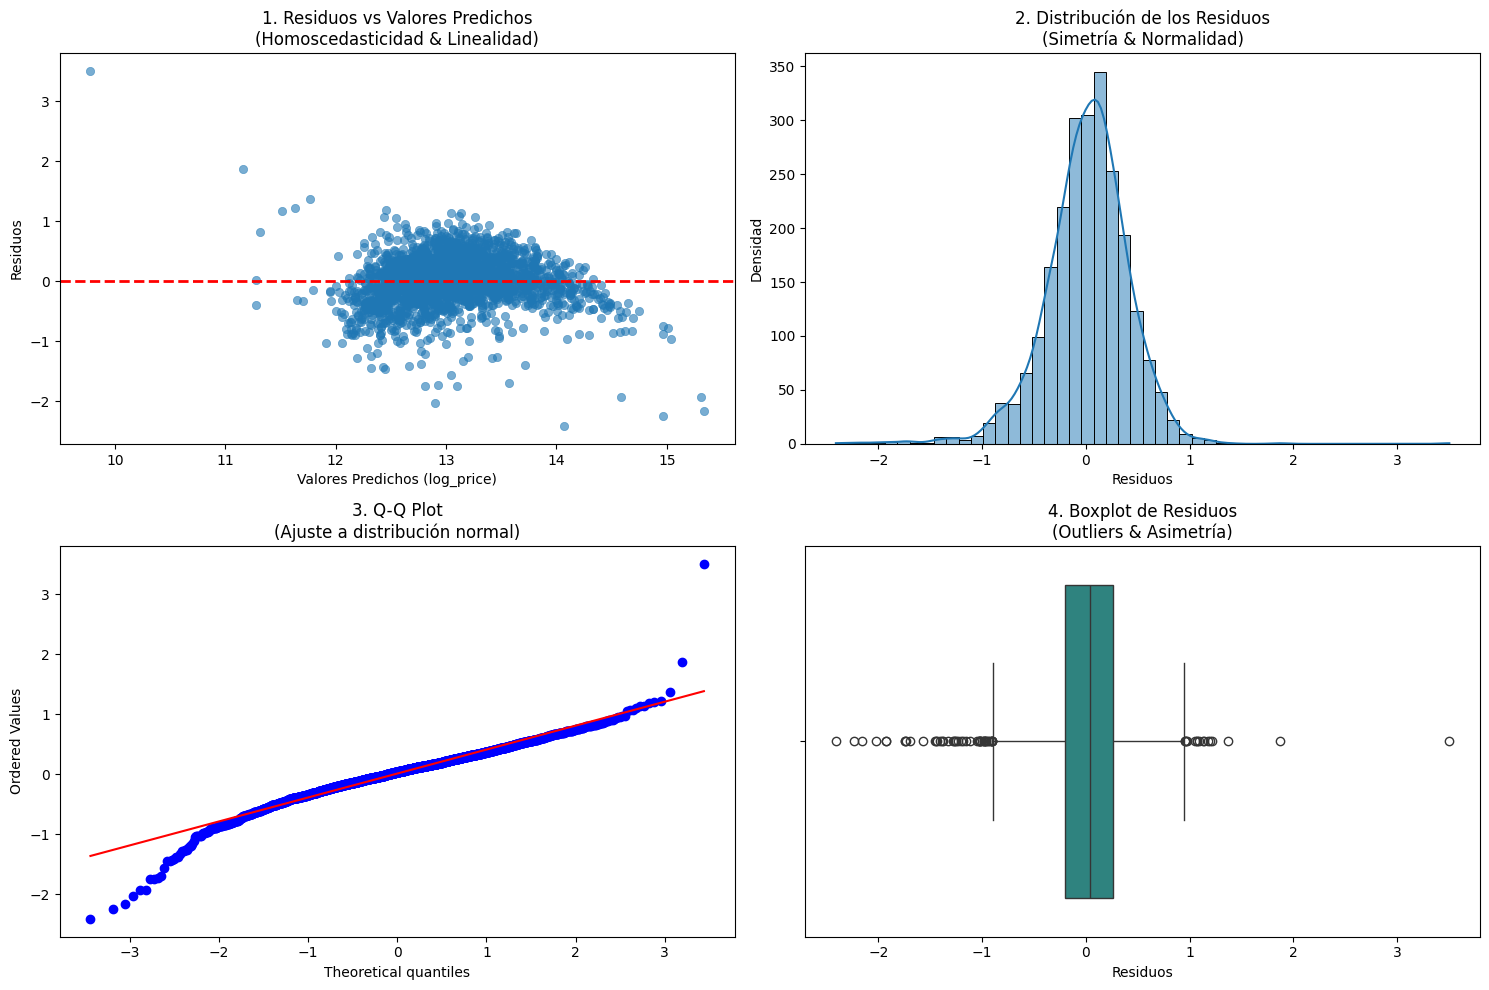

In [11]:
# ============================================================
# 11. EVALUACIÓN DE RESIDUOS
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

# Calcular residuos
residuals = y_val_split - y_pred_val

# Estadísticas descriptivas
print("=== Estadísticas de los Residuos ===")
print(f"Media: {residuals.mean():.4f} (idealmente cercana a 0)")
print(f"Desviación Estándar: {residuals.std():.4f}")
print(f"Skewness: {stats.skew(residuals):.4f}")
print(f"Kurtosis: {stats.kurtosis(residuals):.4f}")

# Test de normalidad (Shapiro-Wilk)
if len(residuals) < 5000:
    stat, p_value = stats.shapiro(residuals)
    print(f"Shapiro-Wilk - Estadístico: {stat:.4f}, p-value: {p_value:.4f}")
    print("⚠️ Interpretación: p < 0.05 sugiere que los residuos se desvían de la normalidad.\n")
else:
    print("Muestra muy grande para Shapiro-Wilk. Confía en los gráficos y pruebas alternativas.\n")

# Visualizaciones de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Residuos vs Valores Predichos
sns.scatterplot(x=y_pred_val, y=residuals, alpha=0.6, edgecolor=None, ax=axes[0,0])
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0,0].set_xlabel('Valores Predichos (log_price)')
axes[0,0].set_ylabel('Residuos')
axes[0,0].set_title('1. Residuos vs Valores Predichos\n(Homoscedasticidad & Linealidad)')

# 2. Histograma + KDE
sns.histplot(residuals, kde=True, bins=50, ax=axes[0,1])
axes[0,1].set_xlabel('Residuos')
axes[0,1].set_ylabel('Densidad')
axes[0,1].set_title('2. Distribución de los Residuos\n(Simetría & Normalidad)')

# 3. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1,0])
axes[1,0].set_title('3. Q-Q Plot\n(Ajuste a distribución normal)')

# 4. Boxplot (detección de outliers)
sns.boxplot(x=residuals, ax=axes[1,1], palette='viridis')
axes[1,1].set_xlabel('Residuos')
axes[1,1].set_title('4. Boxplot de Residuos\n(Outliers & Asimetría)')

plt.tight_layout()
plt.show()

|Gráfico|Qué buscar|Señal de problema|
|-------|----------|-----------------|
|Residuos vs Predichos|Nube de puntos aleatoria centrada en y=0|Formas de cono, curva o bandas → indica heterocedasticidad o no linealidad|
|Histograma|Forma de campana simétrica alrededor de 0|Sesgo marcado o colas largas → los residuos no son normales|
|Q-Q Plot|Puntos alineados sobre la diagonal roja|Desviaciones en los extremos → colas pesadas o asimetría|
|Boxplot|Mediana cerca de 0, bigotes equilibrados|Muchos puntos fuera de los bigotes → outliers que pueden estar influyendo en el modelo|